## Dataset Download
I referred to [this repository](https://github.com/ConstantinSeibold/2DAnatomyDatasets)

In [ ]:
import os
import requests
from zipfile import ZipFile
import json
import random
from pathlib import Path
from tqdm import tqdm
import shutil
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import numpy as np
import json

In [3]:
# Define the URL and the target path
url = "https://www.kaggle.com/api/v1/datasets/download/humansintheloop/teeth-segmentation-on-dental-x-ray-images"
download_path = "/content/archive.zip"
extract_path = "/content/teeth-segmentation-on-dental-x-ray-images"

def download_and_extract(url, download_path, extract_path):
    try:
        # Create the extraction directory if it doesn't exist
        os.makedirs(extract_path, exist_ok=True)

        # Download the file
        print("Downloading dataset...")
        response = requests.get(url, stream=True)
        response.raise_for_status()  # Check for HTTP request errors
        with open(download_path, "wb") as file:
            for chunk in response.iter_content(chunk_size=8192):
                file.write(chunk)
        print("Download complete.")

        # Extract the zip file
        print("Extracting files...")
        with ZipFile(download_path, "r") as zip_ref:
            zip_ref.extractall(extract_path)
        print(f"Files extracted to {extract_path}")

    finally:
        # Remove the ZIP file
        if os.path.exists(download_path):
            os.remove(download_path)
            print("ZIP file deleted.")


# Run the function
download_and_extract(url, download_path, extract_path)

Download complete.
Extracting files...
Files extracted to /content/teeth-segmentation-on-dental-x-ray-images
ZIP file deleted.


In [5]:
def convert_to_coco(ann_dir, img_dir, output_file):
    # Initialize COCO format structure
    coco_format = {
        "info": {
            "description": "Converted Dataset",
            "version": "1.0",
            "year": 2024,
            "contributor": "",
            "date_created": "2024-11-18",
        },
        "licenses": [],
        "images": [],
        "annotations": [],
        "categories": [],
    }

    # Category mapping and ID generator
    category_id_map = {}
    annotation_id = 0  # Unique ID for annotations

    files = sorted(os.listdir(ann_dir))
    # Process each annotation file
    for ann_file in tqdm(files):
        if ann_file.endswith(".json"):
            # Load annotation JSON
            ann_path = os.path.join(ann_dir, ann_file)
            with open(ann_path, "r") as f:
                ann_data = json.load(f)

            # Extract image filename and size
            filename = ann_file.replace(".json", "")
            image_path = os.path.join(img_dir, filename)
            if not os.path.exists(image_path):
                print(f"Image file {filename} not found, skipping...")
                continue

            image_id = len(coco_format["images"]) + 1
            image_info = {
                "id": image_id,
                "file_name": filename,
                "height": ann_data["size"]["height"],
                "width": ann_data["size"]["width"],
            }
            coco_format["images"].append(image_info)

            # Process objects in the annotation
            for obj in ann_data.get("objects", []):
                class_title = obj["classTitle"]
                if class_title not in category_id_map:
                    category_id = int(class_title)
                    category_id_map[class_title] = category_id
                    coco_format["categories"].append(
                        {
                            "id": category_id,
                            "name": class_title,
                            "supercategory": "none",
                        }
                    )
                else:
                    category_id = category_id_map[class_title]

                # Convert polygon points
                points = obj["points"]["exterior"]
                segmentation = [
                    coord for point in points for coord in point
                ]  # Flatten list of points

                # Calculate bounding box (xmin, ymin, width, height)
                x_coords = [p[0] for p in points]
                y_coords = [p[1] for p in points]
                xmin, ymin = min(x_coords), min(y_coords)
                width, height = max(x_coords) - xmin, max(y_coords) - ymin

                # Add annotation
                annotation = {
                    "id": annotation_id,
                    "image_id": image_id,
                    "category_id": category_id,
                    "segmentation": [segmentation],
                    "area": width * height,
                    "bbox": [xmin, ymin, width, height],
                    "iscrowd": 0,
                }
                coco_format["annotations"].append(annotation)
                annotation_id += 1

    # Save COCO JSON to output file
    with open(output_file, "w") as f:
        json.dump(coco_format, f, indent=4)

    print(f"COCO dataset saved to {output_file}")
    return coco_format


def create_splits(coco_data, output_dir, splits=(0.7, 0.1, 0.2)):
    random.seed(42)  # For reproducibility
    images = coco_data["images"]
    random.shuffle(images)

    # Calculate split indices
    total_images = len(images)
    train_count = int(splits[0] * total_images)
    val_count = int(splits[1] * total_images)
    train_images = images[:train_count]
    val_images = images[train_count : train_count + val_count]
    test_images = images[train_count + val_count :]

    # Helper to filter annotations by image IDs
    def filter_annotations(image_ids):
        return [ann for ann in coco_data["annotations"] if ann["image_id"] in image_ids]

    # Create split datasets
    splits_data = {
        "train": {
            "images": train_images,
            "annotations": filter_annotations({img["id"] for img in train_images}),
            "categories": coco_data["categories"],
        },
        "val": {
            "images": val_images,
            "annotations": filter_annotations({img["id"] for img in val_images}),
            "categories": coco_data["categories"],
        },
        "test": {
            "images": test_images,
            "annotations": filter_annotations({img["id"] for img in test_images}),
            "categories": coco_data["categories"],
        },
    }

    # Save splits
    for split_name, split_data in splits_data.items():
        split_path = os.path.join(output_dir, f"{split_name}.json")
        with open(split_path, "w") as f:
            json.dump(split_data, f, indent=4)
        print(f"Saved {split_name} split to {split_path}")

    return splits_data


def create_class_agnostic(coco_data, output_dir, splits_data):
    for split_name, split_data in splits_data.items():
        # Replace all categories with a single class
        agnostic_data = {
            "images": split_data["images"],
            "annotations": [
                {**ann, "category_id": 1} for ann in split_data["annotations"]
            ],
            "categories": [{"id": 1, "name": "classagnostic", "supercategory": "none"}],
        }
        # Save class-agnostic file
        agnostic_path = os.path.join(output_dir, f"{split_name}_classagnostic.json")
        with open(agnostic_path, "w") as f:
            json.dump(agnostic_data, f, indent=4)
        print(f"Saved class-agnostic {split_name} to {agnostic_path}")


# Example usage
if __name__ == "__main__":
    teeth_root = "/content/teeth-segmentation-on-dental-x-ray-images"
    ann_folder = os.path.join(teeth_root, "Teeth Segmentation JSON/d2/ann")
    img_folder = os.path.join(teeth_root, "Teeth Segmentation JSON/d2/img")
    output_coco_file = os.path.join(teeth_root, "teeth_coco.json")

    # Convert to COCO format
    coco_data = convert_to_coco(ann_folder, img_folder, output_coco_file)

    # Create train/val/test splits
    splits = create_splits(coco_data, teeth_root, splits=(0.7, 0.1, 0.2))

    # Create class-agnostic files
    create_class_agnostic(coco_data, teeth_root, splits)

    shutil.move(
        os.path.join(teeth_root, "Teeth Segmentation JSON/d2/img"),
        os.path.join(teeth_root, "img"),
    )

    shutil.rmtree(os.path.join(teeth_root, "Teeth Segmentation JSON"))
    shutil.rmtree(os.path.join(teeth_root, "Teeth Segmentation PNG"))


100%|██████████| 598/598 [00:01<00:00, 594.61it/s]


COCO dataset saved to /content/teeth-segmentation-on-dental-x-ray-images/teeth_coco.json
Saved train split to /content/teeth-segmentation-on-dental-x-ray-images/train.json
Saved val split to /content/teeth-segmentation-on-dental-x-ray-images/val.json
Saved test split to /content/teeth-segmentation-on-dental-x-ray-images/test.json
Saved class-agnostic train to /content/teeth-segmentation-on-dental-x-ray-images/train_classagnostic.json
Saved class-agnostic val to /content/teeth-segmentation-on-dental-x-ray-images/val_classagnostic.json
Saved class-agnostic test to /content/teeth-segmentation-on-dental-x-ray-images/test_classagnostic.json


In [8]:
!cd teeth-segmentation-on-dental-x-ray-images && ls

img			 test.json		   val_classagnostic.json
teeth_coco.json		 train_classagnostic.json  val.json
test_classagnostic.json  train.json


# Data Exploratory

Found 598 images in COCO annotations
Found 15318 total annotated objects


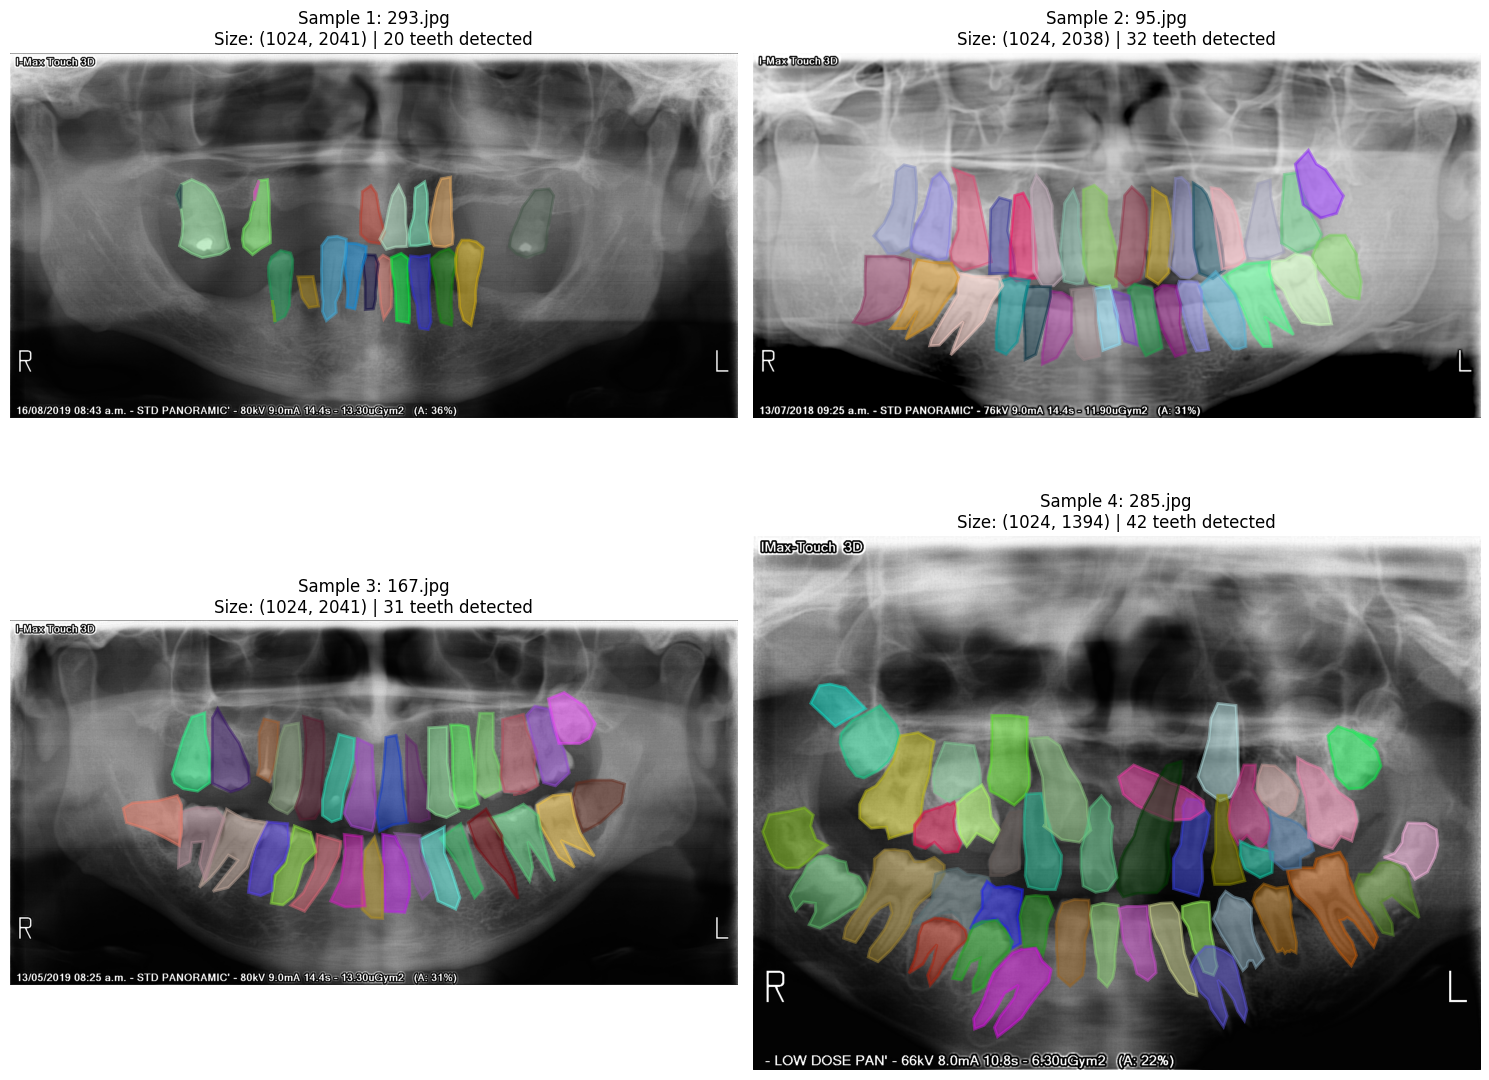

In [11]:
data_dir = Path('/content/teeth-segmentation-on-dental-x-ray-images')
coco_file = data_dir / 'teeth_coco.json'
img_dir = data_dir / 'img'

# Explore dataset structure
def explore_dataset_structure(coco_path):
    with open(coco_path, 'r') as f:
        coco_data = json.load(f)

    print(f"Found {len(coco_data['images'])} images in COCO annotations")
    print(f"Found {len(coco_data['annotations'])} total annotated objects")
    return coco_data

coco_data = explore_dataset_structure(coco_file)

# Visualize sample images with colored annotations
def visualize_samples_with_masks(coco_data, img_dir, n_samples=4):
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    axes = axes.flatten()

    images_info = coco_data['images']
    sample_images = np.random.choice(images_info, min(n_samples, len(images_info)), replace=False)

    # Create annotation lookup map to quickly find annotations by image_id
    ann_map = {}
    for ann in coco_data['annotations']:
        ann_map.setdefault(ann['image_id'], []).append(ann)

    for idx, img_info in enumerate(sample_images):
        # Load image
        img_path = img_dir / img_info['file_name']
        if not img_path.exists():
            axes[idx].set_title("Image missing")
            axes[idx].axis('off')
            continue

        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        axes[idx].imshow(img)
        axes[idx].axis('off')

        img_anns = ann_map.get(img_info['id'], [])
        axes[idx].set_title(f"Sample {idx+1}: {img_info['file_name']}\nSize: {img.shape[:2]} | {len(img_anns)} teeth detected")

        # Draw colored masks
        for ann in img_anns:
            # Generate a random color for each tooth
            color = np.random.rand(3)
            for seg in ann['segmentation']:
                # Segments are flat lists [x1, y1, x2, y2, ...], reshape to (N, 2)
                poly = np.array(seg).reshape(-1, 2)
                patch = patches.Polygon(poly, closed=True, edgecolor=color, facecolor=color, alpha=0.5, linewidth=2)
                axes[idx].add_patch(patch)

    plt.tight_layout()
    plt.savefig('sample_images_colored.png', dpi=150, bbox_inches='tight')
    plt.show()

visualize_samples_with_masks(coco_data, img_dir)


Image 285.jpg has 42 teeth annotated.


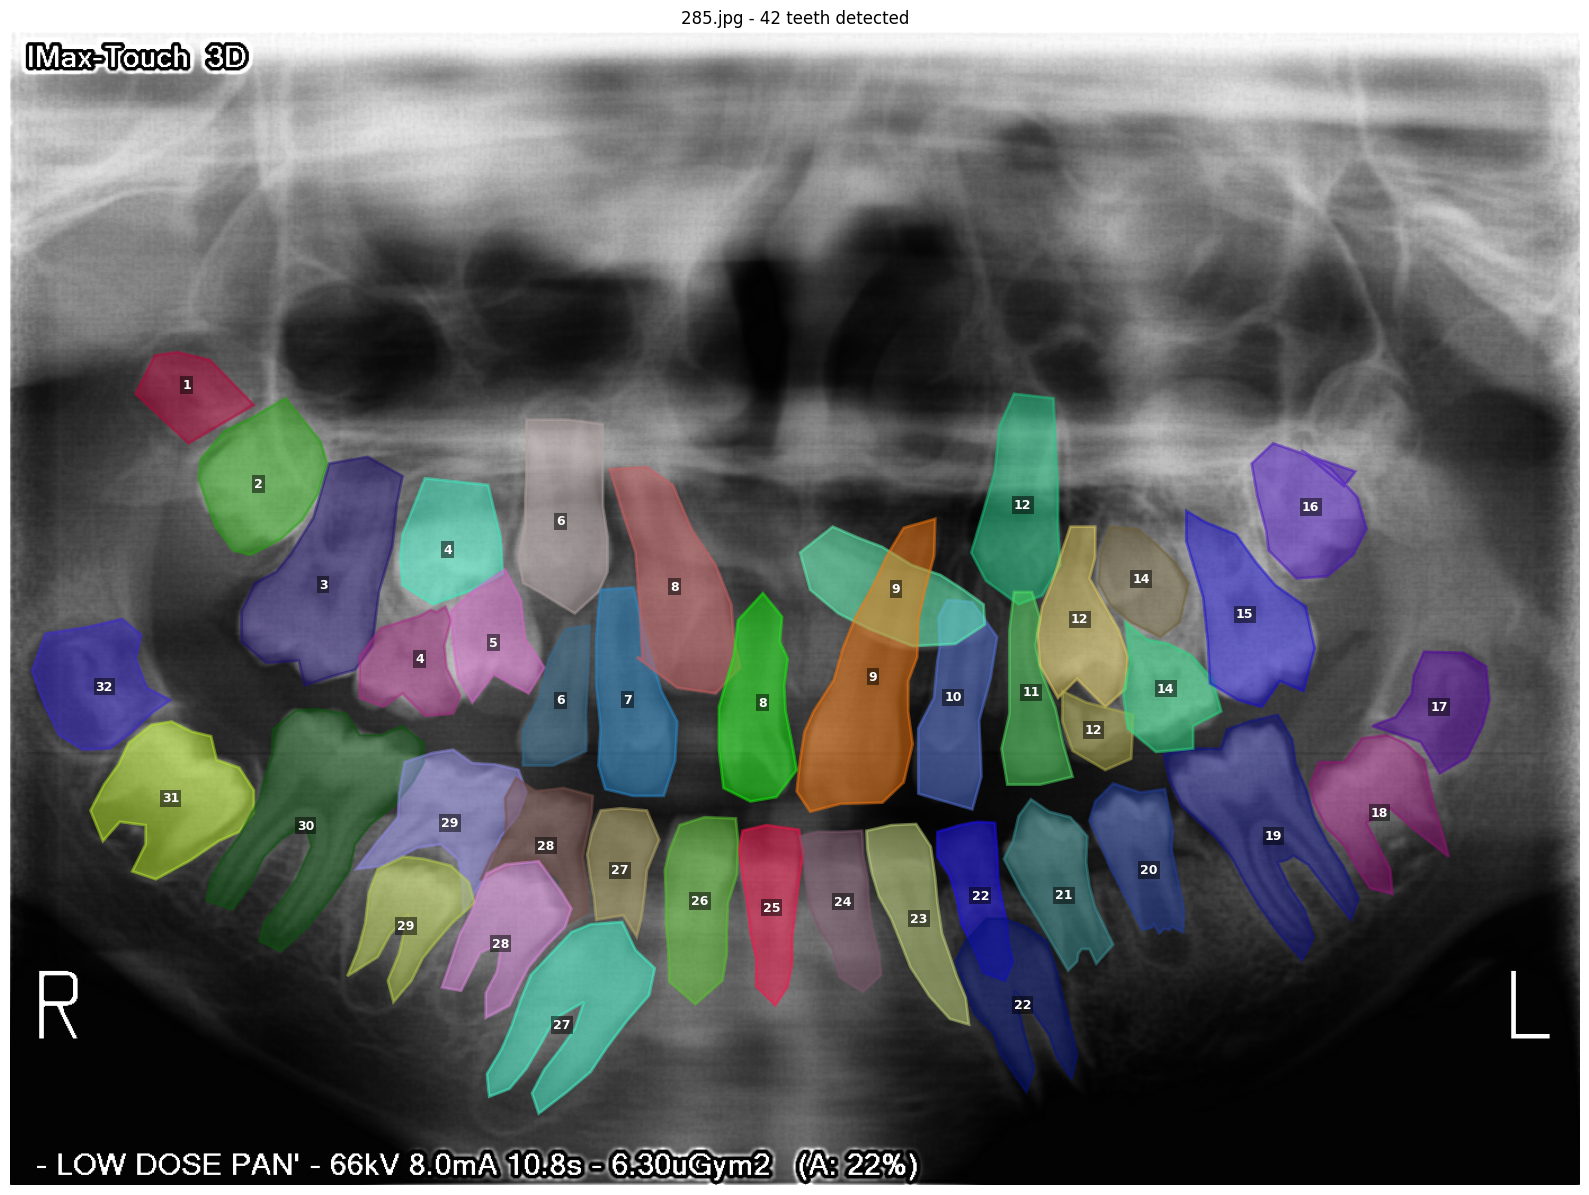

In [13]:
img_filename = '285.jpg'

# Find the image info for 285.jpg
img_info = next((img for img in coco_data['images'] if img['file_name'] == img_filename), None)

if img_info is None:
    print(f"Image {img_filename} not found in COCO data.")
else:
    # Get annotations for this image
    img_anns = [ann for ann in coco_data['annotations'] if ann['image_id'] == img_info['id']]
    print(f"Image {img_filename} has {len(img_anns)} teeth annotated.")

    # Create a mapping from category_id to category name
    cat_map = {cat['id']: cat['name'] for cat in coco_data['categories']}

    # Load and plot image
    img_path = img_dir / img_filename
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    fig, ax = plt.subplots(1, 1, figsize=(16, 14))
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f"{img_filename} - {len(img_anns)} teeth detected")

    for ann in img_anns:
        # Generate a random color for each tooth
        color = np.random.rand(3)
        label = cat_map.get(ann['category_id'], str(ann['category_id']))

        for seg in ann['segmentation']:
            poly = np.array(seg).reshape(-1, 2)
            patch = patches.Polygon(poly, closed=True, edgecolor=color, facecolor=color, alpha=0.5, linewidth=2)
            ax.add_patch(patch)

            # Place the label at the centroid of the polygon
            cx, cy = np.mean(poly[:, 0]), np.mean(poly[:, 1])
            ax.text(cx, cy, label, color='white', fontsize=9, fontweight='bold', ha='center', va='center',
                    bbox=dict(facecolor='black', alpha=0.5, edgecolor='none', pad=1.5))

    plt.tight_layout()
    plt.show()


# Train

In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2
from tqdm import tqdm

# ==========================================
# 1. ERFNet Architecture (Non-bottleneck-1D)
# ==========================================
class DownsamplerBlock(nn.Module):
    def __init__(self, nIn, nOut):
        super().__init__()
        self.conv = nn.Conv2d(nIn, nOut-nIn, (3, 3), stride=2, padding=1, bias=True)
        self.pool = nn.MaxPool2d(2, stride=2)
        self.bn = nn.BatchNorm2d(nOut, eps=1e-3)

    def forward(self, input):
        output = torch.cat([self.conv(input), self.pool(input)], 1)
        output = self.bn(output)
        return F.relu(output)

class NonBottleneck1D(nn.Module):
    def __init__(self, chann, dropprob, dilated):
        super().__init__()
        self.conv3x1_1 = nn.Conv2d(chann, chann, (3, 1), stride=1, padding=(1, 0), bias=True)
        self.conv1x3_1 = nn.Conv2d(chann, chann, (1, 3), stride=1, padding=(0, 1), bias=True)
        self.bn1 = nn.BatchNorm2d(chann, eps=1e-03)
        self.conv3x1_2 = nn.Conv2d(chann, chann, (3, 1), stride=1, padding=(1*dilated, 0), dilation=(dilated, 1), bias=True)
        self.conv1x3_2 = nn.Conv2d(chann, chann, (1, 3), stride=1, padding=(0, 1*dilated), dilation=(1, dilated), bias=True)
        self.bn2 = nn.BatchNorm2d(chann, eps=1e-03)
        self.dropout = nn.Dropout2d(dropprob)

    def forward(self, input):
        output = self.conv3x1_1(input)
        output = F.relu(output)
        output = self.conv1x3_1(output)
        output = self.bn1(output)
        output = F.relu(output)

        output = self.conv3x1_2(output)
        output = F.relu(output)
        output = self.conv1x3_2(output)
        output = self.bn2(output)

        if self.dropout.p != 0:
            output = self.dropout(output)

        return F.relu(output + input)

class Encoder(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.initial_block = DownsamplerBlock(3, 16)

        self.layers = nn.ModuleList()
        self.layers.append(DownsamplerBlock(16, 64))
        for x in range(0, 5):
            self.layers.append(NonBottleneck1D(64, 0.03, 1))
        self.layers.append(DownsamplerBlock(64, 128))
        for x in range(0, 2):
            self.layers.append(NonBottleneck1D(128, 0.3, 2))
            self.layers.append(NonBottleneck1D(128, 0.3, 4))
            self.layers.append(NonBottleneck1D(128, 0.3, 8))
            self.layers.append(NonBottleneck1D(128, 0.3, 16))

    def forward(self, input):
        output = self.initial_block(input)
        for layer in self.layers:
            output = layer(output)
        return output

class UpsamplerBlock(nn.Module):
    def __init__(self, nIn, nOut):
        super().__init__()
        self.conv = nn.ConvTranspose2d(nIn, nOut, 3, stride=2, padding=1, output_padding=1, bias=True)
        self.bn = nn.BatchNorm2d(nOut, eps=1e-3)

    def forward(self, input):
        output = self.conv(input)
        output = self.bn(output)
        return F.relu(output)

class Decoder(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.layers = nn.ModuleList()
        self.layers.append(UpsamplerBlock(128, 64))
        self.layers.append(NonBottleneck1D(64, 0, 1))
        self.layers.append(NonBottleneck1D(64, 0, 1))
        self.layers.append(UpsamplerBlock(64, 16))
        self.layers.append(NonBottleneck1D(16, 0, 1))
        self.layers.append(NonBottleneck1D(16, 0, 1))
        self.output_conv = nn.ConvTranspose2d(16, num_classes, 2, stride=2, padding=0, output_padding=0, bias=True)

    def forward(self, input):
        output = input
        for layer in self.layers:
            output = layer(output)
        output = self.output_conv(output)
        return output

class ERFNet(nn.Module):
    def __init__(self, num_classes):  # 16 layers encoder + 7 layers decoder = 23 layers
        super().__init__()
        self.encoder = Encoder(num_classes)
        self.decoder = Decoder(num_classes)

    def forward(self, input, only_encode=False):
        if only_encode:
            return self.encoder(input)
        else:
            output = self.encoder(input)
            return self.decoder(output)

# ==========================================
# 2. Class Weights Calculation
# ==========================================
def calculate_class_weights(mask_paths, num_classes, target_size=(128, 64), c=1.10):
    """
    w_class = 1 / ln(c + p_class)
    Call this separately for encoder (128x64) and decoder (1024x512) by changing target_size.
    """
    print(f"Calculating class weights for target size {target_size}...")
    pixel_counts = np.zeros(num_classes)
    total_pixels = 0

    for mask_path in tqdm(mask_paths):
        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
        if mask is None: continue
        mask = cv2.resize(mask, target_size, interpolation=cv2.INTER_NEAREST)

        counts = np.bincount(mask.flatten(), minlength=num_classes)
        pixel_counts += counts
        total_pixels += mask.size

    p_class = pixel_counts / total_pixels
    weights = 1 / np.log(c + p_class)
    return torch.FloatTensor(weights)

# ==========================================
# 3. Data Augmentation
# ==========================================
train_transform = A.Compose([
    A.Affine(translate_percent=0.1, p=0.5), # Translations
    A.HorizontalFlip(p=0.5),                # Flip
    A.GaussNoise(p=0.5),                    # Gaussian Noise
    A.GaussianBlur(p=0.5),                  # Gaussian Blur
    A.RandomGamma(p=0.5),                   # Gamma Contrast
    ToTensorV2()
])

# ==========================================
# 4. Training Hyperparameters Setup
# ==========================================
LR = 5e-4
BATCH_SIZE = 1
EPOCHS_ENCODER = 100
EPOCHS_DECODER = 100
TOTAL_EPOCHS = EPOCHS_ENCODER + EPOCHS_DECODER
NUM_CLASSES = 33 # Including background

# Model instantiation
model = ERFNet(num_classes=NUM_CLASSES)

# Optimizer Setup (Adam is commonly used)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

print("ERFNet setup complete with 23 layers, non-bottleneck-1D blocks, and data augmentation pipeline.")


ERFNet setup complete with 23 layers, non-bottleneck-1D blocks, and data augmentation pipeline.


In [21]:
import json
from torch.utils.data import Dataset, DataLoader

class DentalDataset(Dataset):
    def __init__(self, img_dir, ann_file, transform=None):
        self.img_dir = img_dir
        self.transform = transform

        with open(ann_file, 'r') as f:
            self.data = json.load(f)

        self.images = {img['id']: img for img in self.data['images']}
        self.annotations = {}
        for ann in self.data['annotations']:
            self.annotations.setdefault(ann['image_id'], []).append(ann)

        self.img_ids = list(self.images.keys())

    def __len__(self):
        return len(self.img_ids)

    def __getitem__(self, idx):
        img_id = self.img_ids[idx]
        img_info = self.images[img_id]
        img_path = str(self.img_dir / img_info['file_name'])

        # Load image
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Generate mask
        mask = np.zeros((img_info['height'], img_info['width']), dtype=np.uint8)
        anns = self.annotations.get(img_id, [])
        for ann in anns:
            cat_id = ann['category_id'] # Teeth classes 1-32, 0 is background
            for seg in ann['segmentation']:
                poly = np.array(seg).reshape(-1, 2).astype(np.int32)
                cv2.fillPoly(mask, [poly], cat_id)

        # Apply Albumentations transforms if any
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']
        else:
            # Default transform if none provided
            image = torch.from_numpy(image.transpose(2, 0, 1)).float() / 255.0
            mask = torch.from_numpy(mask).long()

        # Ensure image is float between 0-1 and mask is long
        if isinstance(image, torch.Tensor) and image.max() > 1.0:
            image = image.float() / 255.0
        mask = mask.long()

        return image, mask

print("Dataset class defined.")

Dataset class defined.


In [22]:
from pathlib import Path

data_dir = Path('/content/teeth-segmentation-on-dental-x-ray-images')
img_dir = data_dir / 'img'

# Create Datasets
train_dataset = DentalDataset(img_dir, data_dir / 'train.json', transform=train_transform)
val_dataset = DentalDataset(img_dir, data_dir / 'val.json', transform=None) # No augmentation for validation

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")

Training batches: 418
Validation batches: 59


In [23]:
import torchvision.transforms.functional as TF

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

# Loss function (Standard CrossEntropy for now, can be updated with weights later)
criterion = nn.CrossEntropyLoss()

def train_epoch(model, loader, optimizer, criterion, device, only_encode=False, target_size=(512, 1024)):
    model.train()
    running_loss = 0.0

    pbar = tqdm(loader, desc="Training")
    for images, masks in pbar:
        images, masks = images.to(device), masks.to(device)

        # Resize to a fixed size divisible by 16 to avoid downsampling mismatch
        images = TF.resize(images, target_size)
        masks = TF.resize(masks.unsqueeze(1).float(), target_size, interpolation=TF.InterpolationMode.NEAREST).squeeze(1).long()

        optimizer.zero_grad()

        # Forward pass
        outputs = model(images, only_encode=only_encode)

        # If only training encoder, resize masks to match encoder output size (which is 1/8 of input)
        if only_encode:
            masks = F.interpolate(masks.unsqueeze(1).float(), size=outputs.shape[2:], mode='nearest').squeeze(1).long()

        loss = criterion(outputs, masks)

        # Backward pass
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        pbar.set_postfix({'loss': loss.item()})

    return running_loss / len(loader)

def validate_epoch(model, loader, criterion, device, only_encode=False, target_size=(512, 1024)):
    model.eval()
    running_loss = 0.0

    with torch.no_grad():
        for images, masks in tqdm(loader, desc="Validating"):
            images, masks = images.to(device), masks.to(device)

            images = TF.resize(images, target_size)
            masks = TF.resize(masks.unsqueeze(1).float(), target_size, interpolation=TF.InterpolationMode.NEAREST).squeeze(1).long()

            outputs = model(images, only_encode=only_encode)

            if only_encode:
                masks = F.interpolate(masks.unsqueeze(1).float(), size=outputs.shape[2:], mode='nearest').squeeze(1).long()

            loss = criterion(outputs, masks)
            running_loss += loss.item()

    return running_loss / len(loader)

print("Training loop functions defined. You can now start training by running the next cell.")

Training loop functions defined. You can now start training by running the next cell.


In [25]:
# ==========================================
# 5. Start Training
# ==========================================
# Note: This is set to 1 epoch for demonstration.
# Change `epochs_to_run` to EPOCHS_ENCODER (100) to train the encoder fully.
epochs_to_run_encoder = 100

print("--- Training Encoder ---")
for epoch in range(epochs_to_run_encoder):
    print(f"\nEpoch {epoch+1}/{epochs_to_run_encoder}")
    train_loss = train_epoch(model, train_loader, optimizer, criterion, device, only_encode=True)
    val_loss = validate_epoch(model, val_loader, criterion, device, only_encode=True)
    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

# Note: Change to EPOCHS_DECODER (100) to train the decoder fully.
epochs_to_run_decoder = 100

print("\n--- Training Decoder ---")
for epoch in range(epochs_to_run_decoder):
    print(f"\nEpoch {epoch+1}/{epochs_to_run_decoder}")
    train_loss = train_epoch(model, train_loader, optimizer, criterion, device, only_encode=False)
    val_loss = validate_epoch(model, val_loader, criterion, device, only_encode=False)
    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

--- Training Encoder ---

Epoch 1/100


Validating: 100%|██████████| 59/59 [01:02<00:00,  1.06s/it]


Train Loss: 1.4885 | Val Loss: 0.8336

Epoch 2/100


Validating: 100%|██████████| 59/59 [01:05<00:00,  1.12s/it]


Train Loss: 0.8634 | Val Loss: 0.5320

Epoch 3/100


...

Train Loss: 0.3970 | Val Loss: 0.4330

Epoch 6/100


Validating: 100%|██████████| 59/59 [01:03<00:00,  1.08s/it]


Train Loss: 0.3344 | Val Loss: 0.2108

Epoch 7/100


Training:   0%|          | 0/418 [00:02<?, ?it/s]


KeyboardInterrupt: 

In [27]:
# Run this cell immediately after manually stopping/interrupting the training cell above
# to save the intermediate weights from memory.
torch.save(model.state_dict(), 'ERF_interrupted_after_epoch6_model_weights.pth')
print("Saved intermediate model weights to 'ERF_interrupted_after_epoch6_model_weights.pth'!")

Saved intermediate model weights to 'ERF_interrupted_after_epoch6_model_weights.pth'!


In [ ]:
# 1. Load the saved weights
checkpoint_path = 'ERF_interrupted_after_epoch6_model_weights.pth'
model.load_state_dict(torch.load(checkpoint_path, map_location=device))
print(f"Loaded weights from {checkpoint_path}")

# 2. Resume training for the remaining epochs
total_epochs = EPOCHS_ENCODER # 100
completed_epochs = 6
remaining_epochs = total_epochs - completed_epochs

print(f"\n--- Resuming Encoder Training ---")
for epoch in range(remaining_epochs):
    current_epoch = completed_epochs + epoch + 1
    print(f"\nEpoch {current_epoch}/{total_epochs}")

    # Resume training the encoder
    train_loss = train_epoch(model, train_loader, optimizer, criterion, device, only_encode=True)
    val_loss = validate_epoch(model, val_loader, criterion, device, only_encode=True)

    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")


Loaded weights from ERF_interrupted_after_epoch6_model_weights.pth

--- Resuming Encoder Training ---

Epoch 7/100


Validating: 100%|██████████| 59/59 [01:05<00:00,  1.11s/it]


Train Loss: 0.2907 | Val Loss: 0.1802

Epoch 8/100


Validating: 100%|██████████| 59/59 [01:06<00:00,  1.13s/it]


Train Loss: 0.2680 | Val Loss: 0.1795

Epoch 9/100


...

Validating: 100%|██████████| 59/59 [01:03<00:00,  1.08s/it]


Train Loss: 0.1043 | Val Loss: 0.1141

Epoch 50/100


Validating: 100%|██████████| 59/59 [01:05<00:00,  1.11s/it]


Train Loss: 0.1039 | Val Loss: 0.1134

Epoch 51/100


Training:  68%|██████▊   | 283/418 [16:50<08:18,  3.69s/it, loss=0.273]

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

save_path = '/content/drive/MyDrive/ERF_interrupted_after_epoch100_model_weights.pth'
torch.save(model.state_dict(), save_path)
print(f"Saved intermediate model weights to '{save_path}'!")

# Post processing


In [28]:
import numpy as np
import cv2

def post_process_mask(predicted_mask, num_classes=33, min_area=150):
    """
    Cleans up the ERFNet prediction.
    To account for mixed dentition (primary + permanent teeth in children),
    we allow multiple instances of the same tooth class.
    We filter out noise by removing connected components smaller than `min_area`.
    """
    clean_mask = np.zeros_like(predicted_mask)

    # Iterate through each specific tooth class (1 to 32)
    for class_id in range(1, num_classes):
        # Create a binary mask for the current tooth
        tooth_binary = (predicted_mask == class_id).astype(np.uint8)

        if tooth_binary.sum() == 0:
            continue # Model didn't predict this tooth

        # Find connected components (blobs)
        num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(tooth_binary, connectivity=8)

        # Loop through components (ignoring label 0 which is background)
        for i in range(1, num_labels):
            area = stats[i, cv2.CC_STAT_AREA]

            # If the blob is larger than the noise threshold, keep it
            if area >= min_area:
                clean_mask[labels == i] = class_id

    return clean_mask

print("Post-processing function updated for mixed dentition!")


Post-processing function updated for mixed dentition!


### 1. Evaluation Metrics Definition
Here we define the functions to calculate Semantic Segmentation IoU and Bounding Box metrics (Precision, Recall, F1).

In [29]:
def calculate_segmentation_iou(pred_mask, true_mask, num_classes):
    ious = []
    for cls in range(num_classes):
        pred_inds = pred_mask == cls
        target_inds = true_mask == cls

        intersection = np.logical_and(pred_inds, target_inds).sum()
        union = np.logical_or(pred_inds, target_inds).sum()

        if union == 0:
            ious.append(np.nan)  # Ignore classes not present in both GT and Pred
        else:
            ious.append(intersection / union)
    return ious

def extract_bboxes(mask, num_classes, min_area=150):
    '''Extracts bounding boxes from a segmentation mask.'''
    bboxes = []
    for cls in range(1, num_classes):  # Skip background (0)
        cls_mask = (mask == cls).astype(np.uint8)
        if cls_mask.sum() == 0:
            continue

        num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(cls_mask, connectivity=8)
        for i in range(1, num_labels):
            x, y, w, h, area = stats[i]
            if area >= min_area:
                # store as [xmin, ymin, xmax, ymax]
                bboxes.append({'class': cls, 'bbox': [x, y, x+w, y+h]})
    return bboxes

def compute_bbox_iou(boxA, boxB):
    xA, yA = max(boxA[0], boxB[0]), max(boxA[1], boxB[1])
    xB, yB = min(boxA[2], boxB[2]), min(boxA[3], boxB[3])

    interArea = max(0, xB - xA) * max(0, yB - yA)
    if interArea == 0:
        return 0.0

    boxAArea = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    boxBArea = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
    return interArea / float(boxAArea + boxBArea - interArea)

def evaluate_detections(pred_boxes, true_boxes, iou_threshold=0.5):
    TP = 0
    FP = 0
    matched_true_boxes = set()

    for p_box in pred_boxes:
        best_iou = 0
        best_gt_idx = -1

        for gt_idx, t_box in enumerate(true_boxes):
            if p_box['class'] == t_box['class'] and gt_idx not in matched_true_boxes:
                iou = compute_bbox_iou(p_box['bbox'], t_box['bbox'])
                if iou > best_iou:
                    best_iou = iou
                    best_gt_idx = gt_idx

        if best_iou >= iou_threshold:
            TP += 1
            matched_true_boxes.add(best_gt_idx)
        else:
            FP += 1

    FN = len(true_boxes) - len(matched_true_boxes)
    return TP, FP, FN

### 2. Evaluation Loop
Run this cell to evaluate the model on the validation dataset.

In [30]:
def evaluate_full_dataset(model, val_loader, device, num_classes=33, target_size=(512, 1024)):
    model.eval()

    all_ious = []
    total_TP, total_FP, total_FN = 0, 0, 0

    with torch.no_grad():
        for images, true_masks in tqdm(val_loader, desc="Evaluating Metrics"):
            images = images.to(device)
            images = TF.resize(images, target_size)

            # Predict
            outputs = model(images, only_encode=False)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()

            true_masks = true_masks.numpy()

            for i in range(images.size(0)):
                pred_mask = preds[i]
                true_mask = true_masks[i]

                # Resize GT to match prediction shape if necessary
                if pred_mask.shape != true_mask.shape:
                    true_mask = cv2.resize(true_mask, (pred_mask.shape[1], pred_mask.shape[0]), interpolation=cv2.INTER_NEAREST)

                # 1. Semantic Segmentation Eval
                post_pred_mask = post_process_mask(pred_mask, num_classes=num_classes)
                img_ious = calculate_segmentation_iou(post_pred_mask, true_mask, num_classes)
                all_ious.append(img_ious)

                # 2. Bounding Box Eval
                pred_bboxes = extract_bboxes(post_pred_mask, num_classes)
                true_bboxes = extract_bboxes(true_mask, num_classes)

                TP, FP, FN = evaluate_detections(pred_bboxes, true_bboxes)
                total_TP += TP
                total_FP += FP
                total_FN += FN

    # Aggregate Segmentation mIoU
    mean_ious = np.nanmean(np.array(all_ious), axis=0)
    overall_mIoU = np.nanmean(mean_ious)

    # Aggregate Detection Metrics
    precision = total_TP / (total_TP + total_FP) if (total_TP + total_FP) > 0 else 0
    recall = total_TP / (total_TP + total_FN) if (total_TP + total_FN) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    # Approximation for "Accuracy" based on Object Detection Jaccard logic
    accuracy = total_TP / (total_TP + total_FP + total_FN) if (total_TP + total_FP + total_FN) > 0 else 0

    print("\n=== Evaluation Results ===")
    print(f"Semantic Segmentation mIoU: {overall_mIoU * 100:.2f}%")
    print("\n--- Teeth Detection (Bounding Box) ---")
    print(f"Accuracy (TP/(TP+FP+FN)): {accuracy:.2f}")
    print(f"Precision: {precision:.2f}")
    print(f"Recall: {recall:.2f}")
    print(f"F1-score: {f1_score:.2f}")

# Run evaluation
# Make sure your model has been trained adequately before running this,
# otherwise the scores will be near zero.
evaluate_full_dataset(model, val_loader, device, num_classes=NUM_CLASSES)


Evaluating Metrics: 100%|██████████| 59/59 [02:20<00:00,  2.38s/it]


=== Evaluation Results ===
Semantic Segmentation mIoU: 2.33%

--- Teeth Detection (Bounding Box) ---
Accuracy (TP/(TP+FP+FN)): 0.00
Precision: 0.00
Recall: 0.00
F1-score: 0.00


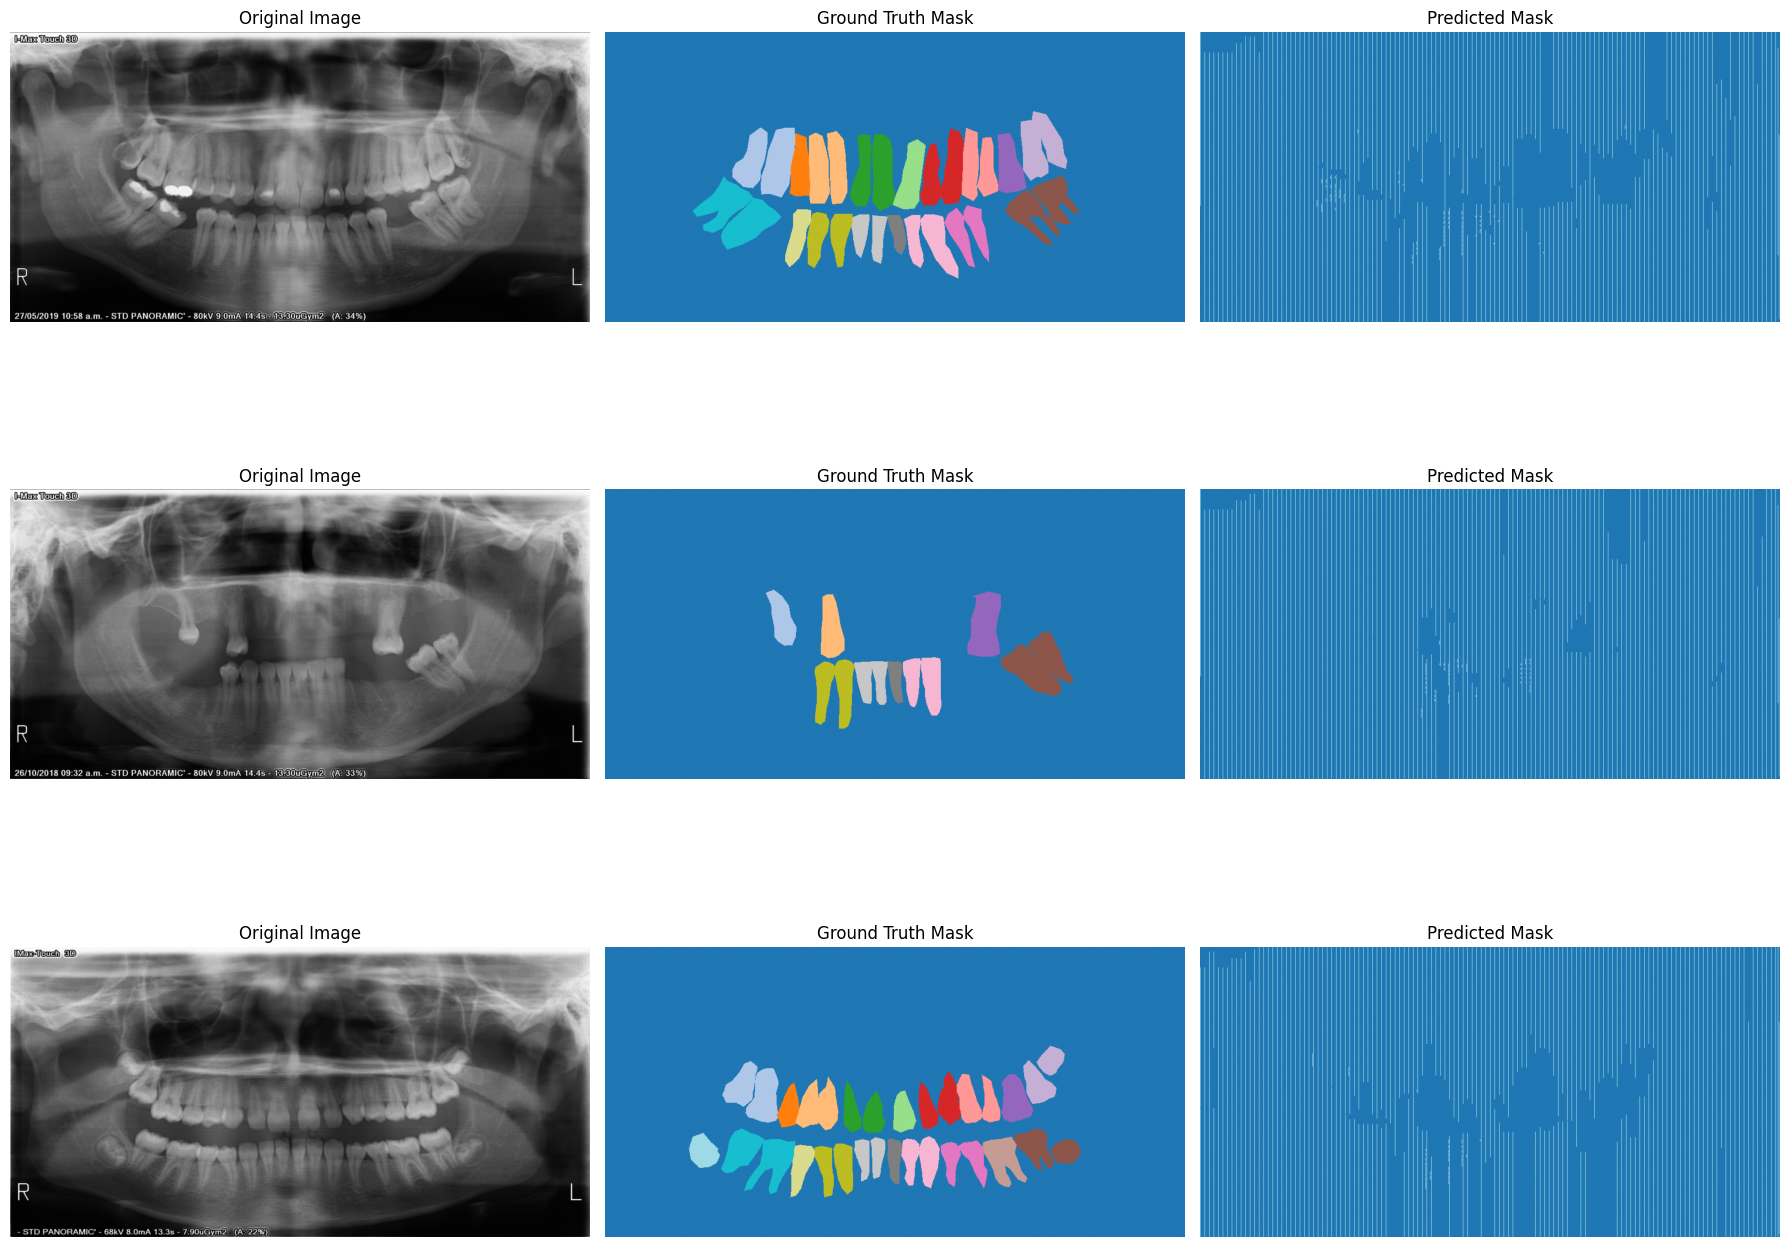

In [31]:
import matplotlib.pyplot as plt
import random

def visualize_predictions(model, dataset, device, num_samples=3, target_size=(512, 1024)):
    model.eval()

    # Select random indices from the dataset
    indices = random.sample(range(len(dataset)), num_samples)

    fig, axes = plt.subplots(num_samples, 3, figsize=(18, 5*num_samples))
    if num_samples == 1:
        axes = [axes]

    for i, idx in enumerate(indices):
        image, true_mask = dataset[idx]

        # Add batch dimension and move to device
        img_tensor = image.unsqueeze(0).to(device)
        img_tensor = TF.resize(img_tensor, target_size)

        # Get prediction
        with torch.no_grad():
            output = model(img_tensor, only_encode=False)
            pred_mask = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()

        # Prepare image for plotting (C, H, W) -> (H, W, C)
        img_plot = TF.resize(image, target_size).permute(1, 2, 0).numpy()

        # Resize Ground Truth to match target size for visualization
        true_mask_resized = TF.resize(true_mask.unsqueeze(0).unsqueeze(0).float(), target_size, interpolation=TF.InterpolationMode.NEAREST).squeeze().numpy()

        # Post process predicted mask to clean up noise
        clean_pred = post_process_mask(pred_mask, num_classes=NUM_CLASSES)

        # Plotting
        axes[i][0].imshow(img_plot)
        axes[i][0].set_title("Original Image")
        axes[i][0].axis('off')

        # Use a colormap like 'tab20' which is good for distinct classes (teeth)
        axes[i][1].imshow(true_mask_resized, cmap='tab20', vmin=0, vmax=NUM_CLASSES)
        axes[i][1].set_title("Ground Truth Mask")
        axes[i][1].axis('off')

        axes[i][2].imshow(clean_pred, cmap='tab20', vmin=0, vmax=NUM_CLASSES)
        axes[i][2].set_title("Predicted Mask")
        axes[i][2].axis('off')

    plt.tight_layout()
    plt.show()

# Visualize 3 random samples from the validation dataset
visualize_predictions(model, val_dataset, device, num_samples=3)
